In [1]:
from sklearn.model_selection import train_test_split
from scripts.data_preprocessing import load_data, drop_high_correlated_features, split_data
from scripts.mlp_model import get_mlp_classifier, train_mlp
from scripts.baseline_model import get_baseline_model, train_baseline
from sklearn.preprocessing import MultiLabelBinarizer
import numpy as np
import pandas as pd

In [2]:
SEED = 5296

In [3]:
splits = {
    "Baseline": {
        "X_train": None,
        "X_test": None,
        "y_train": None,
        "y_test": None
    },
    "MLP": {
        "50/50": {
            "X_train": None,
            "X_test": None,
            "y_train": None,
            "y_test": None
        },
        "60/40": {
            "X_train": None,
            "X_test": None,
            "y_train": None,
            "y_test": None
        },
        "70/30": {
            "X_train": None,
            "X_test": None,
            "y_train": None,
            "y_test": None
        },
        "80/20": {
            "X_train": None,
            "X_test": None,
            "y_train": None,
            "y_test": None
        }
    }
}

In [4]:
X, y = load_data()

X = drop_high_correlated_features(X)

X_train, X_test, y_train, y_test, class_weights = split_data(X, y, 0.2, SEED)
splits["Baseline"]["X_train"] = X_train
splits["Baseline"]["X_test"] = X_test
splits["Baseline"]["y_train"] = y_train
splits["Baseline"]["y_test"] = y_test
#splits["Baseline"]["class_weights"] = class_weights

X_train, X_test, y_train, y_test, class_weights = split_data(X, y, 0.5, SEED)
splits["MLP"]["50/50"]["X_train"] = X_train
splits["MLP"]["50/50"]["X_test"] = X_test
splits["MLP"]["50/50"]["y_train"] = y_train
splits["MLP"]["50/50"]["y_test"] = y_test
#splits["MLP"]["50/50"]["class_weights"] = class_weights

X_train, X_test, y_train, y_test, class_weights = split_data(X, y, 0.4, SEED)
splits["MLP"]["60/40"]["X_train"] = X_train
splits["MLP"]["60/40"]["X_test"] = X_test
splits["MLP"]["60/40"]["y_train"] = y_train
splits["MLP"]["60/40"]["y_test"] = y_test
#splits["MLP"]["60/40"]["class_weights"] = class_weights

X_train, X_test, y_train, y_test, class_weights = split_data(X, y, 0.3, SEED)
splits["MLP"]["70/30"]["X_train"] = X_train
splits["MLP"]["70/30"]["X_test"] = X_test
splits["MLP"]["70/30"]["y_train"] = y_train
splits["MLP"]["70/30"]["y_test"] = y_test
#splits["MLP"]["70/30"]["class_weights"] = class_weights

X_train, X_test, y_train, y_test, class_weights = split_data(X, y, 0.2, SEED)
splits["MLP"]["80/20"]["X_train"] = X_train
splits["MLP"]["80/20"]["X_test"] = X_test
splits["MLP"]["80/20"]["y_train"] = y_train
splits["MLP"]["80/20"]["y_test"] = y_test
#splits["MLP"]["80/20"]["class_weights"] = class_weights

In [5]:
results_all = {}

model = get_mlp_classifier(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    batch_size=32,
    learning_rate_init=1e-3,
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.2,
    n_iter_no_change=15,
    random_state=SEED
)

for split_name, split_data in splits["MLP"].items():
    Xtr = split_data["X_train"]
    Xte = split_data["X_test"]
    ytr = split_data["y_train"]
    yte = split_data["y_test"]
    
    res = train_mlp(
        model,
        Xtr, ytr,
        Xte, yte,
        split_name
    )
    results_all[split_name] = res

In [6]:
model = get_baseline_model(
    loss='log_loss',
    n_estimators=200,
    learning_rate=0.1,
    max_depth=10,
    random_state=SEED
)

split_data = splits["Baseline"]
split_name = "Baseline"
Xtr = split_data["X_train"]
Xte = split_data["X_test"]
ytr = split_data["y_train"]
yte = split_data["y_test"]

res = train_baseline(
    model,
    Xtr, ytr,
    Xte, yte,
    split_name
)
results_all[split_name] = res

In [7]:
results_all

{'50/50': {'split_name': '50/50',
  'n_epochs_trained': 24,
  'best_epoch': np.int64(8),
  'metrics': {'accuracy': 0.650875386199794,
   'precision': 0.6582115571318063,
   'recall': 0.650875386199794,
   'f1': 0.6490437226249568},
  'learning_curves': {'training_loss': [np.float64(1.6499954688501557),
    np.float64(1.214048406093972),
    np.float64(1.0456490669807017),
    np.float64(0.9308885034068508),
    np.float64(0.8487880275616597),
    np.float64(0.7821474354928635),
    np.float64(0.7384561477859768),
    np.float64(0.7183965050662344),
    np.float64(0.6825144672701429),
    np.float64(0.6516950658673298),
    np.float64(0.6261625043007873),
    np.float64(0.608822758008897),
    np.float64(0.5937639520497298),
    np.float64(0.5768711764986136),
    np.float64(0.5640584840901537),
    np.float64(0.5347644271082421),
    np.float64(0.526838147895417),
    np.float64(0.5088807332068717),
    np.float64(0.5000843289711354),
    np.float64(0.4758385411578262),
    np.float64(

In [8]:
to_dataframe = {name: results_all[name]['metrics'] for name in results_all}
baseline_results = pd.DataFrame(to_dataframe)

baseline_results

,50/50,60/40,70/30,80/20,Baseline
accuracy,0.650875,0.697555,0.692967,0.704370,0.740360
precision,0.658212,0.704854,0.695657,0.707517,0.747899
recall,0.650875,0.697555,0.692967,0.704370,0.740360
f1,0.649044,0.699689,0.692610,0.704122,0.742469


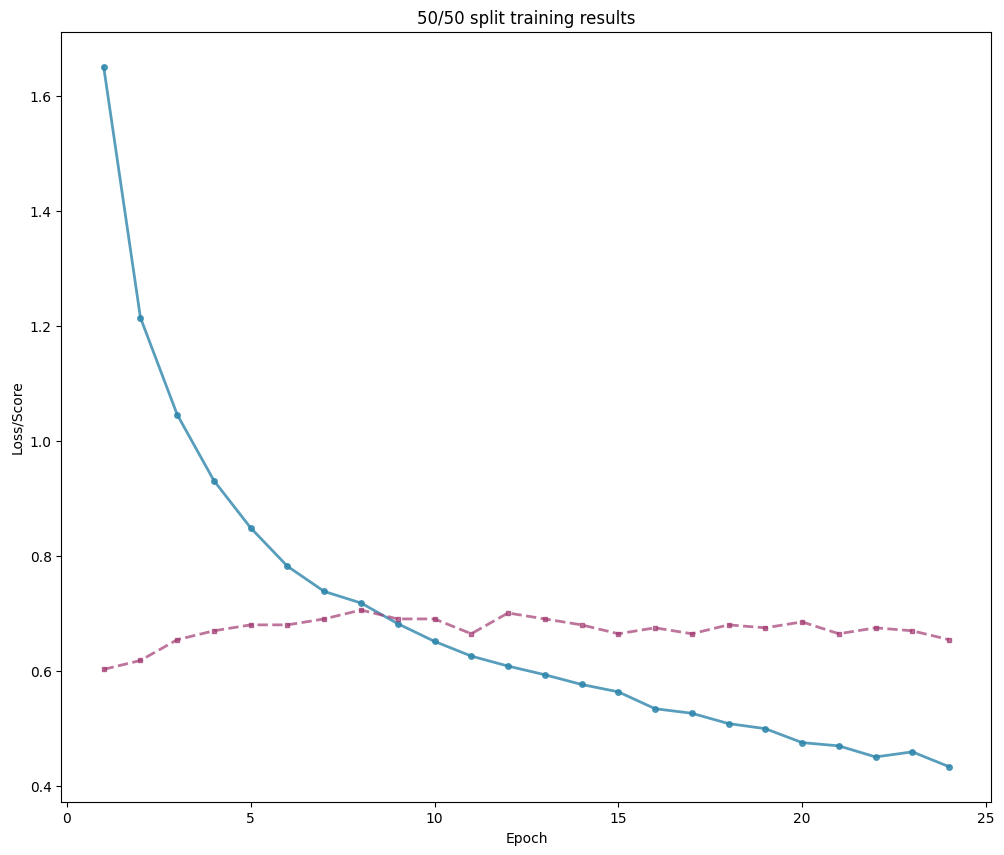

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

result_dict = results_all['50/50']
learning_curves = result_dict['learning_curves']
training_loss = learning_curves['training_loss']
validation_score = learning_curves['validation_score']

epochs = range(1, len(training_loss) + 1)

plt.figure(figsize=(12,10))
plt.plot(epochs, training_loss, 'o-', color='#2E86AB', linewidth=2, 
           markersize=4, label='Training Loss', alpha=0.8)
# Plot validation score on secondary axis
plt.plot(epochs, validation_score, 's--', color='#A23B72', linewidth=2, 
            markersize=3, label='Validation Score', alpha=0.7)
plt.title("50/50 split training results")
plt.ylabel("Loss/Score")
plt.xlabel("Epoch")
plt.savefig("50_50_split_training.png")
plt.show()

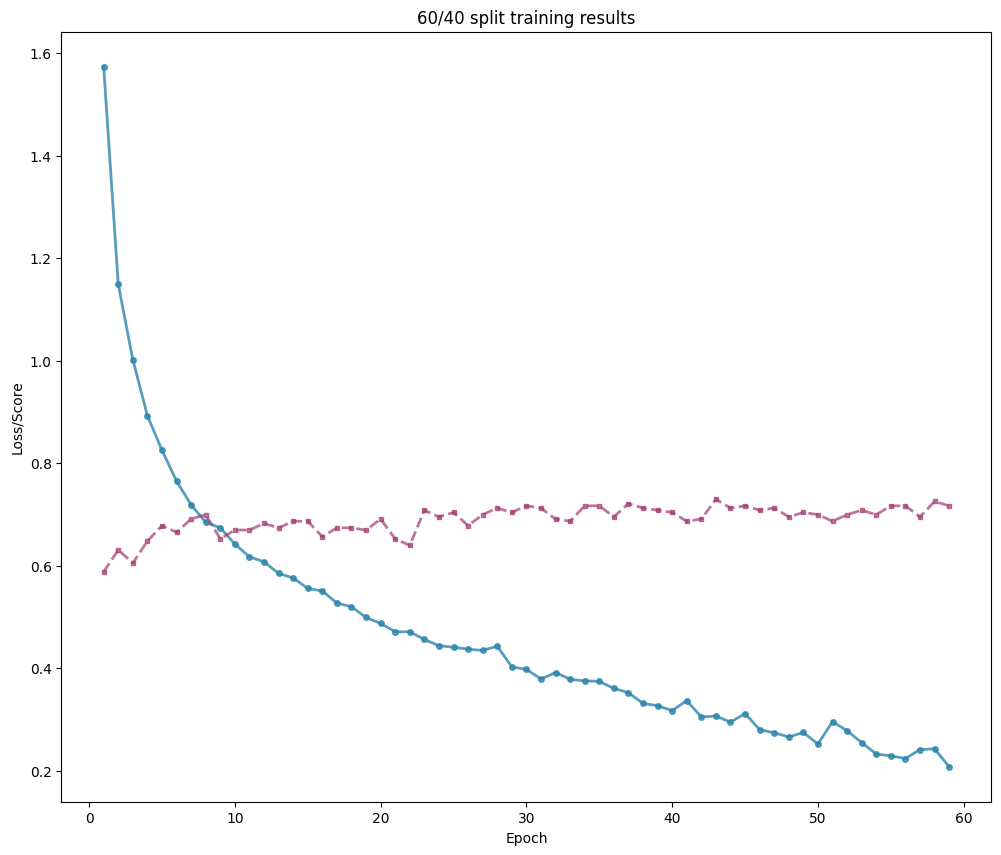

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

result_dict = results_all['60/40']
learning_curves = result_dict['learning_curves']
training_loss = learning_curves['training_loss']
validation_score = learning_curves['validation_score']

epochs = range(1, len(training_loss) + 1)

plt.figure(figsize=(12,10))
plt.plot(epochs, training_loss, 'o-', color='#2E86AB', linewidth=2, 
           markersize=4, label='Training Loss', alpha=0.8)
# Plot validation score on secondary axis
plt.plot(epochs, validation_score, 's--', color='#A23B72', linewidth=2, 
            markersize=3, label='Validation Score', alpha=0.7)
plt.title("60/40 split training results")
plt.ylabel("Loss/Score")
plt.xlabel("Epoch")
plt.savefig("60_40_split_training.png")
plt.show()

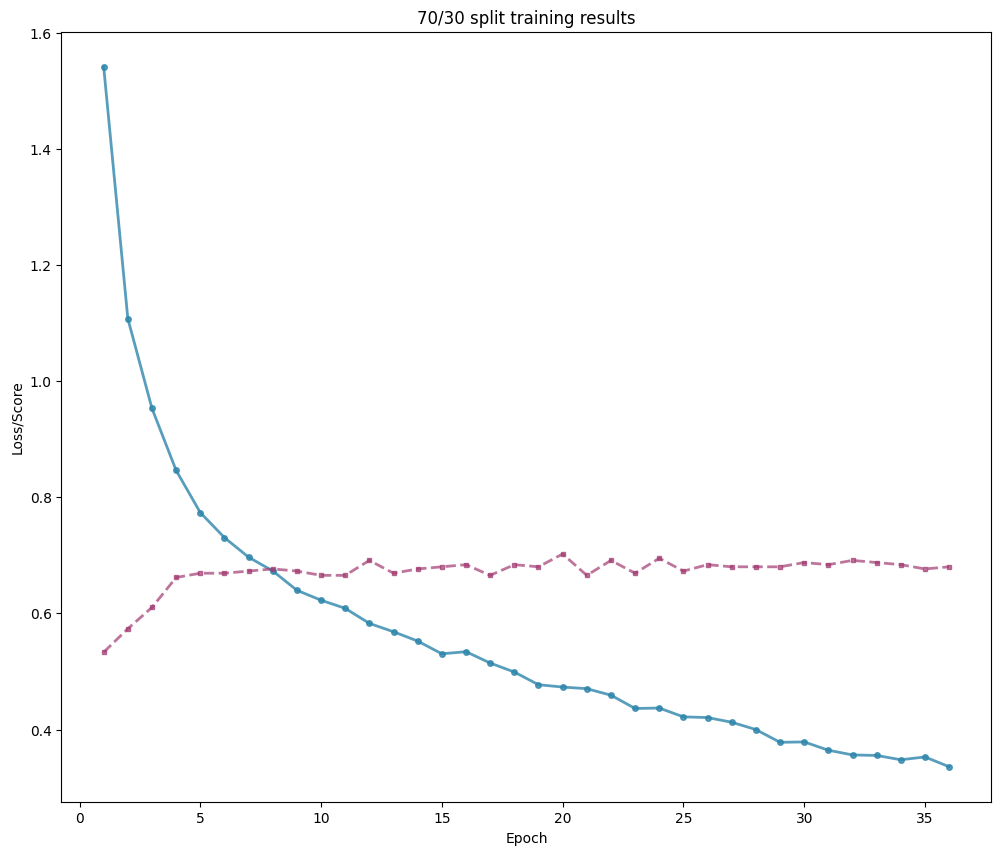

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

result_dict = results_all['70/30']
learning_curves = result_dict['learning_curves']
training_loss = learning_curves['training_loss']
validation_score = learning_curves['validation_score']

epochs = range(1, len(training_loss) + 1)

plt.figure(figsize=(12,10))
plt.plot(epochs, training_loss, 'o-', color='#2E86AB', linewidth=2, 
           markersize=4, label='Training Loss', alpha=0.8)
# Plot validation score on secondary axis
plt.plot(epochs, validation_score, 's--', color='#A23B72', linewidth=2, 
            markersize=3, label='Validation Score', alpha=0.7)
plt.title("70/30 split training results")
plt.ylabel("Loss/Score")
plt.xlabel("Epoch")
plt.savefig("70_30_split_training.png")
plt.show()

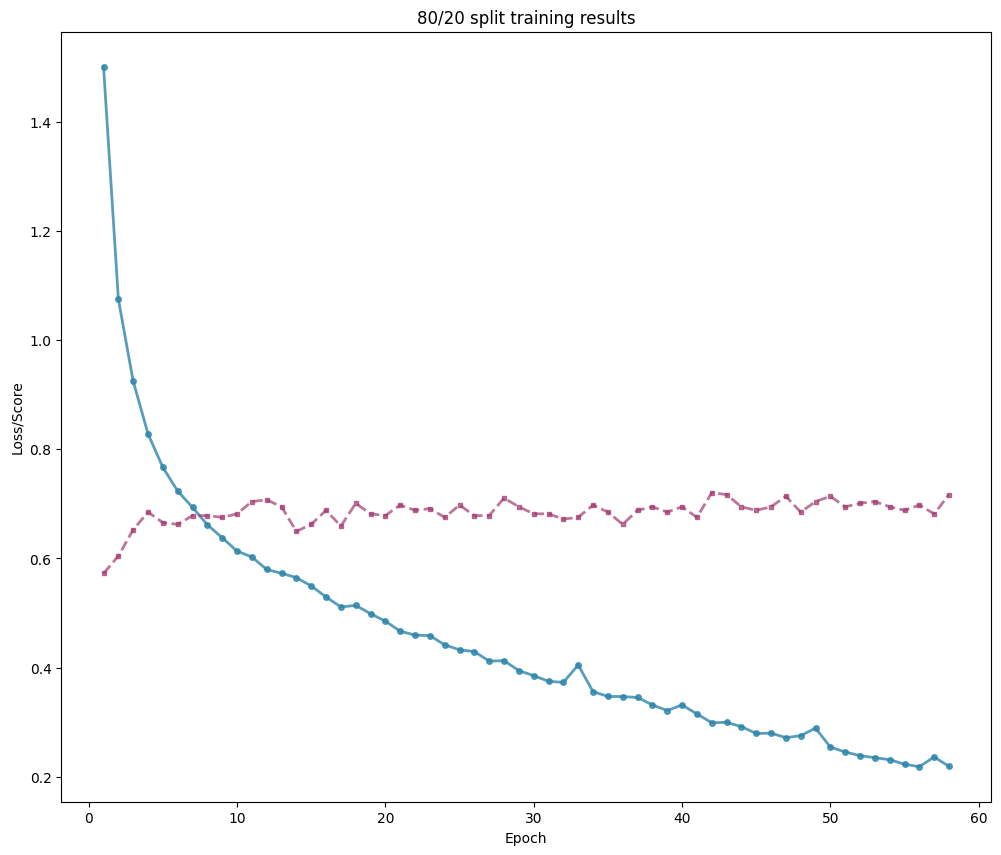

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

result_dict = results_all['80/20']
learning_curves = result_dict['learning_curves']
training_loss = learning_curves['training_loss']
validation_score = learning_curves['validation_score']

epochs = range(1, len(training_loss) + 1)

plt.figure(figsize=(12,10))
plt.plot(epochs, training_loss, 'o-', color='#2E86AB', linewidth=2, 
           markersize=4, label='Training Loss', alpha=0.8)
# Plot validation score on secondary axis
plt.plot(epochs, validation_score, 's--', color='#A23B72', linewidth=2, 
            markersize=3, label='Validation Score', alpha=0.7)
plt.title("80/20 split training results")
plt.ylabel("Loss/Score")
plt.xlabel("Epoch")
plt.savefig("80_20_split_training.png")
plt.show()

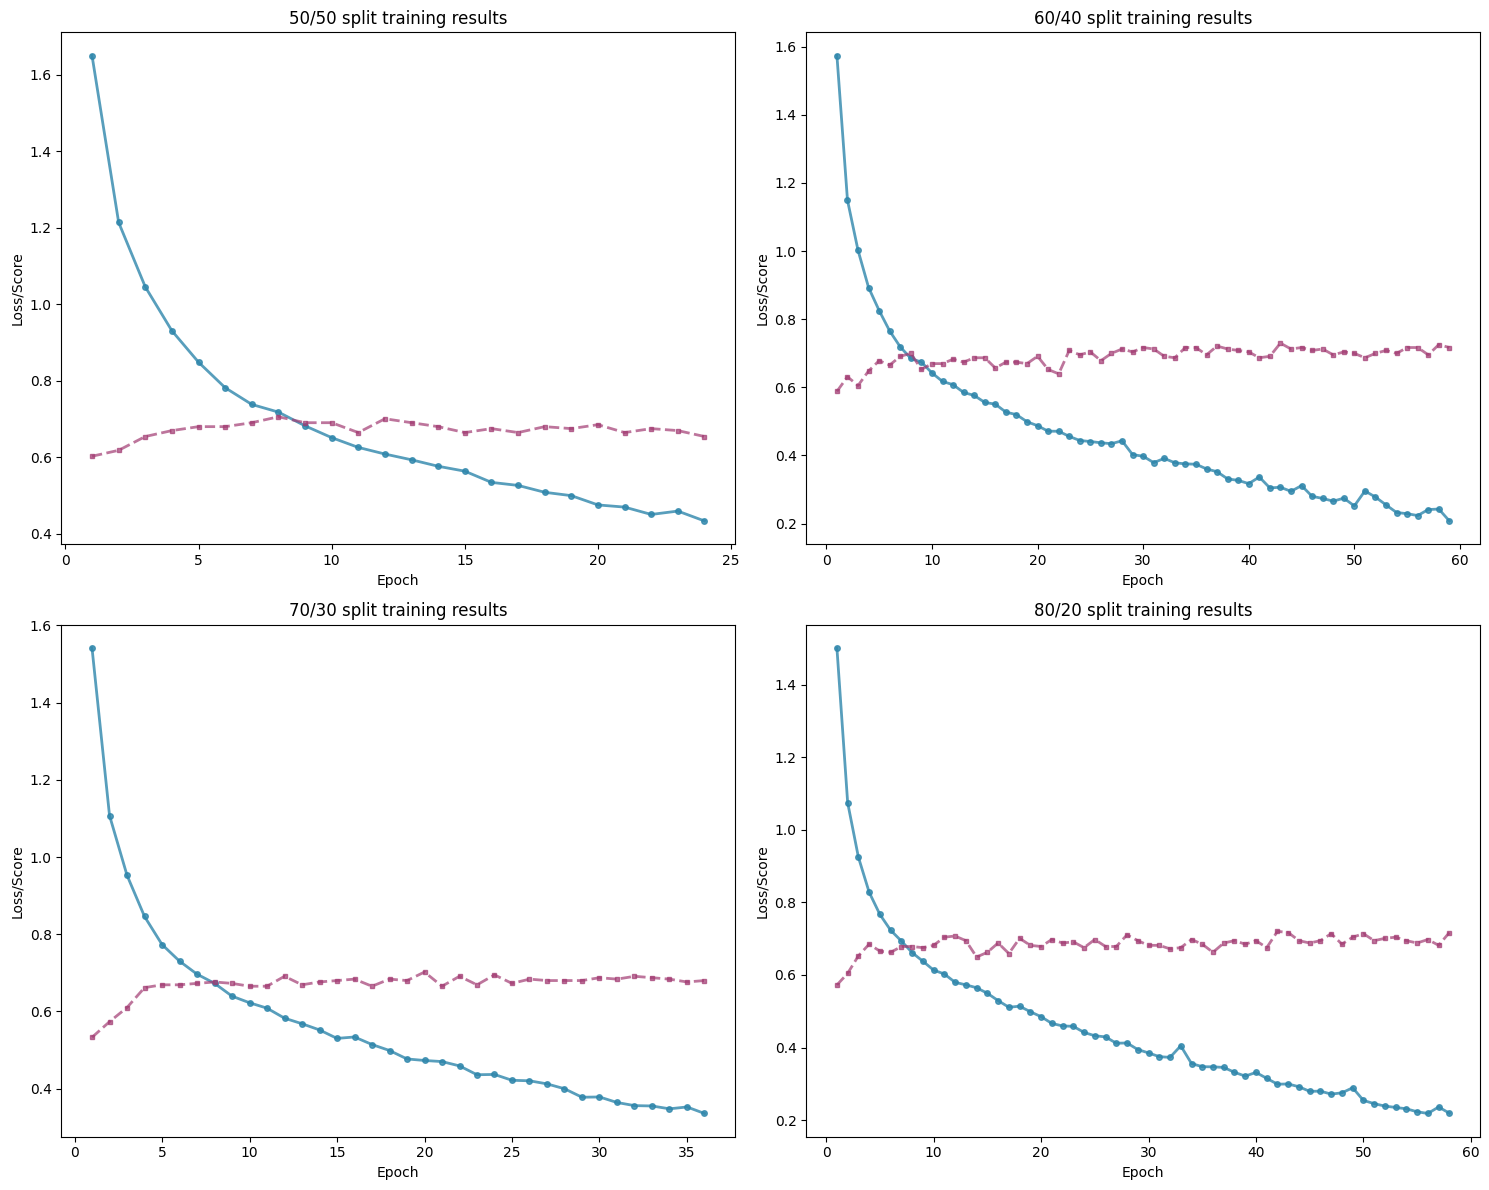

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

result_dict = results_all['50/50']
learning_curves = result_dict['learning_curves']
training_loss = learning_curves['training_loss']
validation_score = learning_curves['validation_score']

epochs = range(1, len(training_loss) + 1)

plt.subplots(2, 2, figsize=(15, 12))
plt.subplot(2, 2, 1)
plt.plot(epochs, training_loss, 'o-', color='#2E86AB', linewidth=2, 
           markersize=4, label='Training Loss', alpha=0.8)
plt.plot(epochs, validation_score, 's--', color='#A23B72', linewidth=2, 
            markersize=3, label='Validation Score', alpha=0.7)
plt.title("50/50 split training results")
plt.ylabel("Loss/Score")
plt.xlabel("Epoch")
plt.tight_layout()

result_dict = results_all['60/40']
learning_curves = result_dict['learning_curves']
training_loss = learning_curves['training_loss']
validation_score = learning_curves['validation_score']

epochs = range(1, len(training_loss) + 1)

plt.subplot(2, 2, 2)
plt.plot(epochs, training_loss, 'o-', color='#2E86AB', linewidth=2, 
           markersize=4, label='Training Loss', alpha=0.8)
plt.plot(epochs, validation_score, 's--', color='#A23B72', linewidth=2, 
            markersize=3, label='Validation Score', alpha=0.7)
plt.title("60/40 split training results")
plt.ylabel("Loss/Score")
plt.xlabel("Epoch")
plt.tight_layout()

result_dict = results_all['70/30']
learning_curves = result_dict['learning_curves']
training_loss = learning_curves['training_loss']
validation_score = learning_curves['validation_score']

epochs = range(1, len(training_loss) + 1)

plt.subplot(2, 2, 3)
plt.plot(epochs, training_loss, 'o-', color='#2E86AB', linewidth=2, 
           markersize=4, label='Training Loss', alpha=0.8)
plt.plot(epochs, validation_score, 's--', color='#A23B72', linewidth=2, 
            markersize=3, label='Validation Score', alpha=0.7)
plt.title("70/30 split training results")
plt.ylabel("Loss/Score")
plt.xlabel("Epoch")
plt.tight_layout()

result_dict = results_all['80/20']
learning_curves = result_dict['learning_curves']
training_loss = learning_curves['training_loss']
validation_score = learning_curves['validation_score']

epochs = range(1, len(training_loss) + 1)

plt.subplot(2, 2, 4)
plt.plot(epochs, training_loss, 'o-', color='#2E86AB', linewidth=2, 
           markersize=4, label='Training Loss', alpha=0.8)
plt.plot(epochs, validation_score, 's--', color='#A23B72', linewidth=2, 
            markersize=3, label='Validation Score', alpha=0.7)
plt.title("80/20 split training results")
plt.ylabel("Loss/Score")
plt.xlabel("Epoch")
plt.tight_layout()
plt.savefig("training_curves.png")
plt.show()

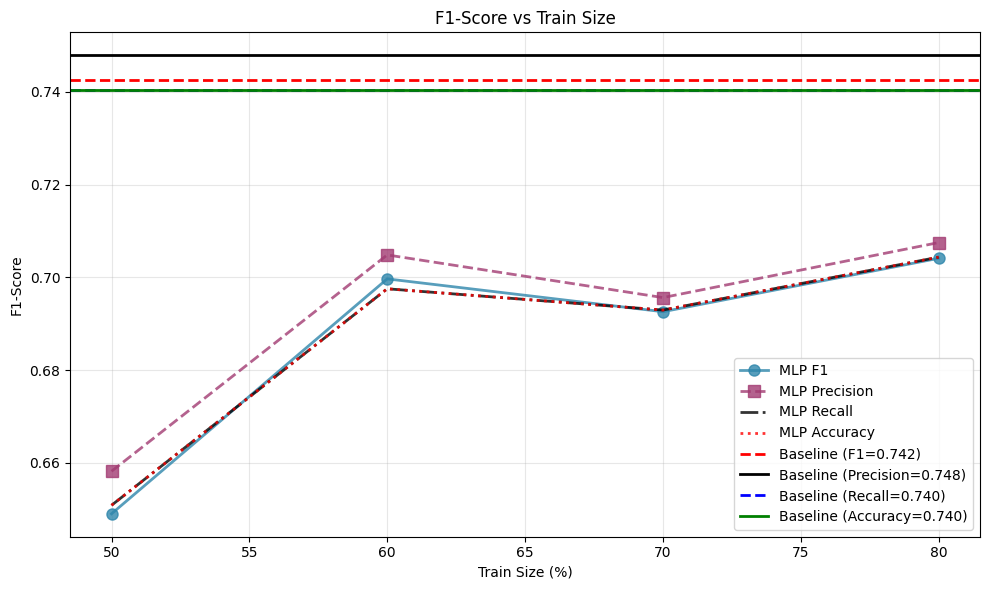

In [41]:
import matplotlib.pyplot as plt

# Data
train_sizes = [50, 60, 70, 80]  # train percentage
mlp_f1 = [results_all['50/50']['metrics']['f1'],
          results_all['60/40']['metrics']['f1'], 
          results_all['70/30']['metrics']['f1'],
          results_all['80/20']['metrics']['f1']]
baseline_f1 = results_all['Baseline']['metrics']['f1']

mlp_precision = [results_all['50/50']['metrics']['precision'],
          results_all['60/40']['metrics']['precision'], 
          results_all['70/30']['metrics']['precision'],
          results_all['80/20']['metrics']['precision']]
baseline_precision = results_all['Baseline']['metrics']['precision']

mlp_recall = [results_all['50/50']['metrics']['recall'],
          results_all['60/40']['metrics']['recall'], 
          results_all['70/30']['metrics']['recall'],
          results_all['80/20']['metrics']['recall']]
baseline_recall = results_all['Baseline']['metrics']['recall']

mlp_accuracy = [results_all['50/50']['metrics']['accuracy'],
          results_all['60/40']['metrics']['accuracy'], 
          results_all['70/30']['metrics']['accuracy'],
          results_all['80/20']['metrics']['accuracy']]
baseline_accuracy = results_all['Baseline']['metrics']['accuracy']

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, mlp_f1, 'o-', color='#2E86AB', linewidth=2, 
         markersize=8, label='MLP F1', alpha=0.8)
plt.plot(train_sizes, mlp_precision, 's--', color='#A23B72', linewidth=2, 
         markersize=8, label='MLP Precision', alpha=0.8)
plt.plot(train_sizes, mlp_recall, 'k-.', linewidth=2, 
         markersize=8, label='MLP Recall', alpha=0.8)
plt.plot(train_sizes, mlp_accuracy, 'r:', linewidth=2, 
         markersize=8, label='MLP Accuracy', alpha=0.8)
plt.axhline(y=baseline_f1, color='red', linestyle='--', linewidth=2, 
            label=f'Baseline (F1={baseline_f1:.3f})')
plt.axhline(y=baseline_precision, color='black', linestyle='-', linewidth=2, 
            label=f'Baseline (Precision={baseline_precision:.3f})')
plt.axhline(y=baseline_recall, color='blue', linestyle='--', linewidth=2, 
            label=f'Baseline (Recall={baseline_recall:.3f})')
plt.axhline(y=baseline_accuracy, color='green', linestyle='-', linewidth=2, 
            label=f'Baseline (Accuracy={baseline_accuracy:.3f})')

plt.xlabel('Train Size (%)')
plt.ylabel('F1-Score')
plt.title('F1-Score vs Train Size')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('baseline_vs_train_size.png')
plt.show()